In [1]:
# =============================================================================
# Autoencoders & Variational Autoencoders
# =============================================================================
# ---------------------------------------------------------------------------
# SCENE 1 — you describe a face to a sketch artist
# ---------------------------------------------------------------------------
# You see a person. You cannot send the artist a photo. You can only say
# a few facts:
#   "round face, glasses, short hair, smiling"
#
# The artist draws from those facts. The drawing is close, not pixel-perfect.
#
# That's an autoencoder:
#   YOU          = encoder   (turn a rich thing into a short description)
#   THE FACTS    = z         (the short description — also called "latent")
#   THE ARTIST   = decoder   (turn the short description back into a picture)
#
# Nobody cares if the sketch is 100% identical. We care that the SHORT
# DESCRIPTION captured what mattered.
#
#
# ---------------------------------------------------------------------------
# SCENE 2 — zip files (almost the same, but dumber)
# ---------------------------------------------------------------------------
# Zip:  big file → small file → unzip back to the same bytes.
# Zip is a FIXED recipe. It does not learn.
#
# An autoencoder LEARNS its own recipe from examples:
#   see many photos  →  get good at "what to keep in the short description"
#   so unzip-the-neural-way still looks like the original photo.
#
# Zip must be perfect. Autoencoders are allowed to be a bit lossy —
# like JPEG. A slightly blurry rebuild is OK if the gist survived.
#
#
# ---------------------------------------------------------------------------
# SCENE 3 — a tiny number example (so it's not only metaphors)
# ---------------------------------------------------------------------------
# Suppose each "photo" is just 4 numbers (imagine brightness of 4 pixels):
#
#   input x = [1.0,  0.9,  0.1,  0.0]
#
# Encoder squashes that to 2 numbers:
#   z = [0.8, -0.2]
#
# Decoder expands z back to 4 numbers:
#   rebuild x̂ = [0.95, 0.88, 0.12, 0.04]
#
# Close enough. Training's only job: nudge the encoder/decoder so this
# gap gets smaller on lots of examples.
#
# If we forced z to be 4 numbers too, the net could copy [1, 0.9, 0.1, 0]
# and "succeed" without understanding anything. That's why z is SMALLER
# than x — we make copying impossible. That's the bottleneck.
#
#
# ---------------------------------------------------------------------------
# THREE everyday uses (why anyone bothers)
# ---------------------------------------------------------------------------
# 1) Fingerprints
#    Two sales calls that "feel similar" should get similar z.
#    Then you can search: "find calls like this one" without comparing
#    raw audio.
#
# 2) Denoising
#    Feed a noisy version in, ask it to rebuild the clean version.
#    Like teaching it to ignore static on a phone line.
#
# 3) "That's weird"
#    If a new example will NOT rebuild well, it doesn't look like training
#    data. Useful as a simple alarm (odd audio, odd screenshot, odd log).
#
# Notice: in 1 and 3 you might throw the rebuild away and only keep z
# or the error score.
#
#
# ---------------------------------------------------------------------------
# How it trains (same homework energy as MiniGPT, different question)
# ---------------------------------------------------------------------------
# MiniGPT homework: "what word comes next?"
# Autoencoder homework: "can you redraw what I just showed you?"
#
# Show x → get x̂ → measure "how far is x̂ from x?" → twist knobs.
# Repeat. Encoder gets better at describing. Decoder gets better at drawing.
#
#
# ---------------------------------------------------------------------------
# NOW THE VAE — same sketch artist, but they can also invent faces
# ---------------------------------------------------------------------------
# Plain autoencoder: one input → one exact z → one rebuild.
#   It's a photocopier with a tiny memory. Great at rebuilding. Awkward at
#   inventing a NEW face it never saw.
#
# Why awkward? Its z's are like secret locker numbers scattered all over
# a huge building. If you pick a random locker, it's empty. Decode garbage.
#
# VAE changes the rule:
#   Don't give one locker number.
#   Give a NEIGHBORHOOD: "around locker 12, plus or minus a bit."
#
# Then:
#   - at train time we pick a random locker in that neighborhood and decode
#   - later we can wander the hallway of neighborhoods and decode NEW faces
#
# Two extra names (only because papers use them):
#   μ  (mu)    = the middle of the neighborhood
#   σ  (sigma) = how wide the neighborhood is
#   sample z   = "stand near μ, take a small random step of size σ"
#
# Extra homework for a VAE (besides "rebuild well"):
#   keep those neighborhoods in the SAME part of town, overlapping a bit,
#   not one house in Tokyo and one in Lima. Then a random walk still
#   lands in a real neighborhood → decoder draws something plausible.
#
#
# Example, same 4 pixels:
#   AE:   x → z = [0.8, -0.2]              → rebuild
#   VAE:  x → μ = [0.8, -0.2],  σ = [0.1, 0.1]
#         pick z = [0.83, -0.17] this time  → rebuild
#         next time maybe [0.74, -0.25]     → slightly different rebuild
#
# Mix two neighborhoods (smile + glasses) → decoder can draw "smiling
# person with glasses" even if that exact photo wasn't in the dataset.
# That's the generative trick.
#
#
# ---------------------------------------------------------------------------
# One table to keep them straight
# ---------------------------------------------------------------------------
#   What you want                         Use
#   ----------------------------------    ------------------------
#   Finish a sentence                     GPT
#   Compress / fingerprint / denoise      Autoencoder
#   Compress AND invent new examples      VAE
#
#
# ---------------------------------------------------------------------------

In [12]:
# Setup
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# MNIST: images are [0,1], shape [1, 28, 28]
transform = transforms.Compose([transforms.ToTensor()])

train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_data  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

batch_size = 128
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader  = DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Train samples: {len(train_data)}, Test samples: {len(test_data)}")

Using device: cpu
Train samples: 60000, Test samples: 10000


Epoch  1 | BCE Loss: 0.2142
Epoch  2 | BCE Loss: 0.1314
Epoch  3 | BCE Loss: 0.1166
Epoch  4 | BCE Loss: 0.1093
Epoch  5 | BCE Loss: 0.1045
Epoch  6 | BCE Loss: 0.1018
Epoch  7 | BCE Loss: 0.0998
Epoch  8 | BCE Loss: 0.0982
Epoch  9 | BCE Loss: 0.0970
Epoch 10 | BCE Loss: 0.0960


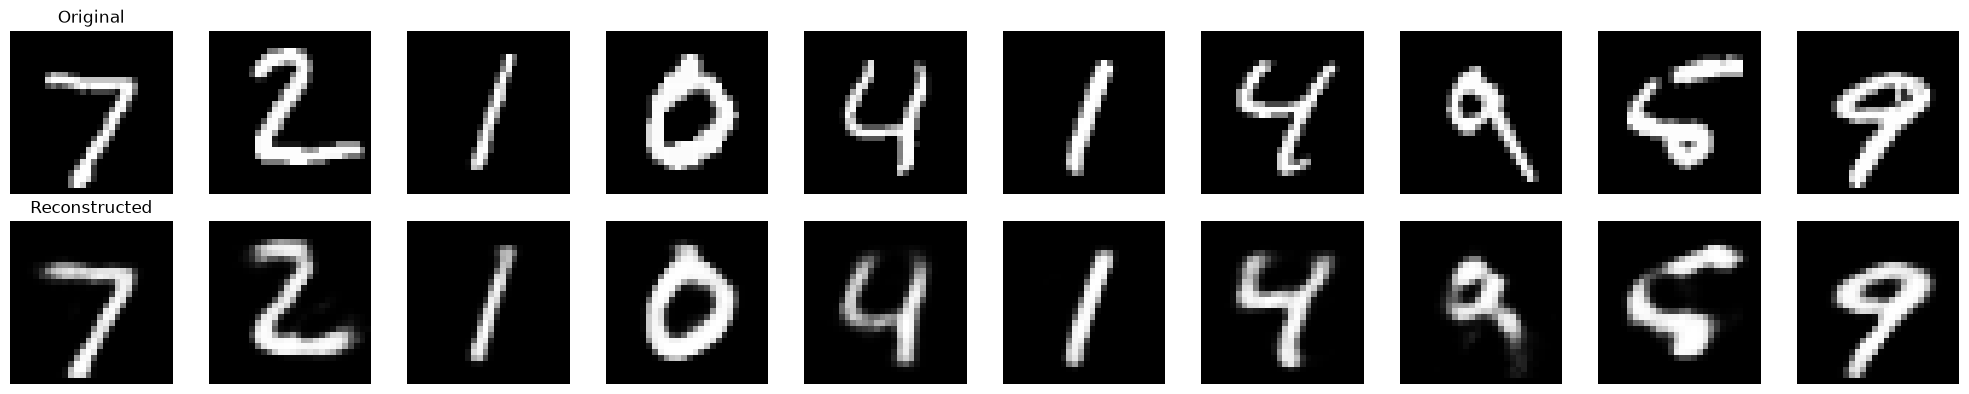

In [13]:
# =============================================================================
# AUTOENCODER FROM SCRATCH — MNIST digits through a 32-number description
# =============================================================================
#
# This cell is Scene 1 in code: encoder describes, decoder sketches.
#
# MNIST photo is 28×28 = 784 pixels. We refuse to keep all 784.
# We keep only 32 numbers (latent_dim). Then we try to redraw the digit.
#
#   [28×28 image] --flatten--> [784] --encoder--> [32] --decoder--> [784]
#
# Labels (0–9) are ignored (`for x, _ in train_loader`).
# Homework is "redraw this picture", not "name the digit".
#

class Autoencoder(nn.Module):
    """MLP autoencoder: 784 → 128 → 32 → 128 → 784."""

    def __init__(self, input_dim=784, hidden_dim=128, latent_dim=32):
        super().__init__()
        # Encoder = "you describing the face" (wide → narrow)
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim),
            nn.ReLU()
        )
        # Decoder = "sketch artist" (narrow → wide)
        # Sigmoid: each pixel predicted in [0, 1], same range as MNIST tensors
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        # x starts as [batch, 1, 28, 28]; Linear wants [batch, 784]
        z = self.encoder(x.view(x.size(0), -1))
        x_recon = self.decoder(z)
        return x_recon  # [batch, 784]  (not yet an image)


def train_autoencoder(model, train_loader, epochs=10, lr=1e-3):
    """Show digits, ask for a redraw, punish mismatch, twist knobs."""
    optimizer = optim.Adam(model.parameters(), lr=lr)
    model.train()
    for epoch in range(epochs):
        total_loss = 0.0
        for x, _ in train_loader:          # `_` = digit label, unused
            x = x.to(device)
            x_flat = x.view(x.size(0), -1)  # target pixels, same 784 layout

            x_recon = model(x)
            # BCE: treats each pixel as "how on is this?" in 0..1
            # (common for MNIST). Lower = rebuild closer to original.
            loss = F.binary_cross_entropy(x_recon, x_flat, reduction="mean")

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * x.size(0)

        avg_loss = total_loss / len(train_loader.dataset)
        print(f"Epoch {epoch+1:2d} | BCE Loss: {avg_loss:.4f}")


ae = Autoencoder(latent_dim=32).to(device)
train_autoencoder(ae, train_loader, epochs=10)


def show_reconstructions(model, test_loader, num_images=10, is_vae=False):
    """Top row = real digits. Bottom row = decoder's sketches."""
    model.eval()
    x, _ = next(iter(test_loader))
    x = x[:num_images].to(device)

    with torch.no_grad():
        if is_vae:
            x_recon, _, _ = model(x)
        else:
            x_recon = model(x)

    x_recon = x_recon.view(num_images, 1, 28, 28).cpu()

    fig, axes = plt.subplots(2, num_images, figsize=(2 * num_images, 4))
    for i in range(num_images):
        axes[0, i].imshow(x[i].cpu().squeeze(), cmap="gray")
        axes[0, i].axis("off")
        axes[1, i].imshow(x_recon[i].squeeze(), cmap="gray")
        axes[1, i].axis("off")

    axes[0, 0].set_title("Original")
    axes[1, 0].set_title("Reconstructed")
    plt.tight_layout()
    plt.show()


show_reconstructions(ae, test_loader)

# ---------------------------------------------------------------------------
# HOW TO READ THE OUTPUT (your run)
# ---------------------------------------------------------------------------
# Epoch  1 | BCE Loss: 0.2142
#   Random knobs. Rebuilds are fog. Loss is "average pixel disagreement".
#   0.21 is a starting point, not a grade out of 100.
#
# Epoch  2 | 0.1314
#   Big drop. The net found the easy pattern: most pixels are black
#   background, ink is in the middle.
#
# Epochs 3–10 | 0.1166 → 0.0960
#   Steady smaller drops. It's learning stroke shapes, not just "be dark".
#   Healthy curve: fast early, then slow. That's normal.
#
# Plot: 2 rows × 10 digits
#   Top    = original test images (the model did NOT train on these)
#   Bottom = reconstructions
#   Expected: blurry but you can still read the digit. Soft edges are
#   the tax for squeezing 784 pixels through 32 numbers — like JPEG.
#
# If bottom is empty/noise after 10 epochs: check device, data download,
# or that Sigmoid + BCE still match (pixels in [0, 1]).
#
# Next: same pictures, but a VAE so we can invent new digits from z.


In [14]:
# =============================================================================
# VAE FROM SCRATCH — same sketch artist, but the description is a neighborhood
# =============================================================================
#
# Plain AE (last cell): one photo → one exact z (32 numbers) → one sketch.
#
# VAE: one photo → a neighborhood in z-space → pick a random point there
#      → sketch. That extra randomness is why we can later invent new digits.
#
# Names in the code:
#   mu      = middle of the neighborhood
#   logvar  = log(width²)  — we store log-variance because it's nicer to train
#             than a width that must stay positive
#   z       = mu + noise * width     (the random locker we actually use)
#
# Two models:
#   vae_20  = 20-number neighborhoods  (better sketches)
#   vae_2d  = 2-number neighborhoods   (we can plot them on a sheet of paper)
#

class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20):
        super().__init__()
        self.latent_dim = latent_dim

        # Shared "look at the photo" layers, then TWO heads:
        #   mu_layer      → where the neighborhood sits
        #   logvar_layer  → how wide it is
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )
        self.mu_layer = nn.Linear(hidden_dim, latent_dim)
        self.logvar_layer = nn.Linear(hidden_dim, latent_dim)

        # Same idea as AE decoder: neighborhood point → 784 pixels in [0, 1]
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x.view(x.size(0), -1))
        return self.mu_layer(h), self.logvar_layer(h)

    def reparameterize(self, mu, logvar):
        # "Stand at mu, take a small random step."
        # Trick: eps is random but we don't need to backprop through it.
        # Gradients still flow through mu and std. That's the reparameterization trick.
        std = torch.exp(0.5 * logvar)   # width = exp(0.5 * log variance)
        eps = torch.randn_like(std)     # random N(0,1) step
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar


def vae_loss(x_recon, x, mu, logvar, beta=1.0):
    """Two homeworks added together.

    1) recon: sketch should still look like the photo  (same spirit as AE)
    2) KL:    neighborhoods should live in the SAME part of town
              (near a simple blob around 0). Otherwise random z's decode
              to garbage — empty lockers all over the building.

    beta: turn the KL homework up/down. 1.0 = treat both equally here.
    """
    # Sum over pixels, then average over the batch so the number is "per image"
    recon_loss = F.binary_cross_entropy(
        x_recon,
        x.view(x.size(0), -1),
        reduction="sum"
    ) / x.size(0)

    # Closed-form KL: "how far is this neighborhood from the standard blob?"
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1).mean()

    total_loss = recon_loss + beta * kl_loss
    return total_loss, recon_loss, kl_loss


def train_vae(model, train_loader, epochs=10, lr=1e-3, beta=1.0):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    model.train()

    for epoch in range(epochs):
        total_loss = 0.0
        total_recon = 0.0
        total_kl = 0.0

        for x, _ in train_loader:
            x = x.to(device)

            x_recon, mu, logvar = model(x)
            loss, recon, kl = vae_loss(x_recon, x, mu, logvar, beta)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * x.size(0)
            total_recon += recon.item() * x.size(0)
            total_kl += kl.item() * x.size(0)

        n = len(train_loader.dataset)
        print(
            f"Epoch {epoch+1:2d} | Loss: {total_loss/n:.4f} | "
            f"Recon: {total_recon/n:.4f} | KL: {total_kl/n:.4f}"
        )


# Better sketches (20-D). Then a 2-D map we can actually plot later.
vae_20 = VAE(latent_dim=20).to(device)
train_vae(vae_20, train_loader, epochs=10)

vae_2d = VAE(latent_dim=2).to(device)
train_vae(vae_2d, train_loader, epochs=10)

# ---------------------------------------------------------------------------
# HOW TO READ THE OUTPUT (your run — two blocks of 10 epochs)
# ---------------------------------------------------------------------------
# Print shape:  Loss = Recon + KL     (beta=1)
#   Recon = "how wrong is the sketch?"     (want down)
#   KL    = "are neighborhoods clustered in town?" (usually rises a bit, then settles)
#
# --- First block = vae_20 (20-number descriptions) ---
# Epoch  1 | Loss: 175.70 | Recon: 167.95 | KL: 7.76
#   Recon is huge vs the AE's 0.21 — NOT a fair compare of "skill".
#   AE used mean BCE per pixel. VAE used SUM over 784 pixels, then / batch.
#   Roughly: 0.21 * 784 ≈ 165. Same ballpark as 168. Different yardstick.
#
# Epoch  2 | Loss: 129.29 | Recon: 115.14 | KL: 14.15
#   Sketches get better (recon ↓). Neighborhoods spread into a real map (KL ↑).
#   That KL rise is OK: epoch 1 neighborhoods were too timid / collapsed.
#
# Epochs 3–10 | Loss 118 → 103 | Recon 101 → 84 | KL 16 → 20
#   Both homeworks active. Loss falling overall = net is improving.
#   KL leveling near ~20 = "town" has a stable size, not exploding.
#
# --- Second block = vae_2d (only 2 numbers — a poster map) ---
# Epoch  1 | Loss: 184.62 | Recon: 180.80 | KL: 3.83
# Epoch 10 | Loss: 143.85 | Recon: 137.54 | KL: 6.31
#   Recon stays WORSE than vae_20 (137 vs 84). Of course: 2 numbers cannot
#   hold as much as 20. That's the cost of a plottable map.
#   KL stays smaller too (~6 vs ~20): a 2-D town is tighter.
#
# Healthy VAE: recon down, KL up-then-flat, total loss down.
# Unhealthy: recon ↓ but KL → 0  (ignores neighborhoods, acts like a shy AE)
#            or KL explodes     (neighborhoods fly to Tokyo and Lima).
#
# Next cells usually: show reconstructions, sample random z → new digits,
# scatter the 2-D map colored by digit 0–9.


Epoch  1 | Loss: 175.7013 | Recon: 167.9450 | KL: 7.7563
Epoch  2 | Loss: 129.2914 | Recon: 115.1379 | KL: 14.1534
Epoch  3 | Loss: 117.8871 | Recon: 101.4414 | KL: 16.4457
Epoch  4 | Loss: 112.5621 | Recon: 94.7834 | KL: 17.7787
Epoch  5 | Loss: 109.6299 | Recon: 91.1437 | KL: 18.4861
Epoch  6 | Loss: 107.4999 | Recon: 88.5935 | KL: 18.9063
Epoch  7 | Loss: 106.0243 | Recon: 86.8525 | KL: 19.1718
Epoch  8 | Loss: 104.9344 | Recon: 85.5130 | KL: 19.4214
Epoch  9 | Loss: 103.9776 | Recon: 84.4104 | KL: 19.5673
Epoch 10 | Loss: 103.3481 | Recon: 83.6325 | KL: 19.7156
Epoch  1 | Loss: 184.6244 | Recon: 180.7993 | KL: 3.8251
Epoch  2 | Loss: 160.8976 | Recon: 155.6367 | KL: 5.2609
Epoch  3 | Loss: 154.9148 | Recon: 149.2780 | KL: 5.6368
Epoch  4 | Loss: 151.4657 | Recon: 145.6272 | KL: 5.8384
Epoch  5 | Loss: 149.1160 | Recon: 143.1505 | KL: 5.9656
Epoch  6 | Loss: 147.5887 | Recon: 141.5247 | KL: 6.0640
Epoch  7 | Loss: 146.3428 | Recon: 140.1824 | KL: 6.1604
Epoch  8 | Loss: 145.4970 | R

Epoch  1 | DAE Loss: 0.2334
Epoch  2 | DAE Loss: 0.1533
Epoch  3 | DAE Loss: 0.1385
Epoch  4 | DAE Loss: 0.1294
Epoch  5 | DAE Loss: 0.1235
Epoch  6 | DAE Loss: 0.1190
Epoch  7 | DAE Loss: 0.1157
Epoch  8 | DAE Loss: 0.1135
Epoch  9 | DAE Loss: 0.1121
Epoch 10 | DAE Loss: 0.1110


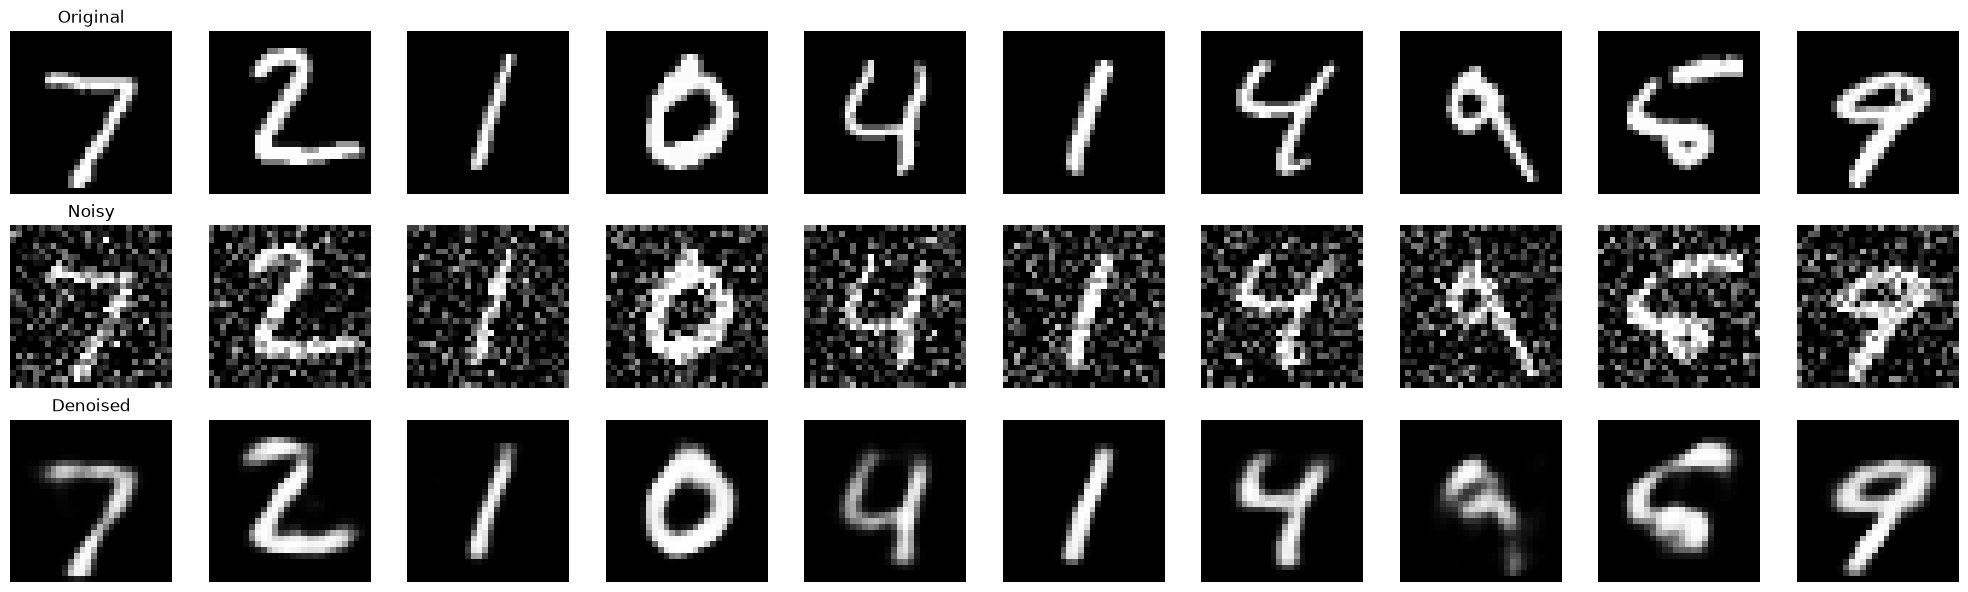

Epoch  1 | Loss: 193.5769 | Recon: 185.5401 | KL: 2.0092
Epoch  2 | Loss: 174.6430 | Recon: 161.8071 | KL: 3.2090
Epoch  3 | Loss: 169.9734 | Recon: 155.4044 | KL: 3.6422
Epoch  4 | Loss: 167.4196 | Recon: 151.7874 | KL: 3.9080
Epoch  5 | Loss: 165.4146 | Recon: 148.9720 | KL: 4.1106
Epoch  6 | Loss: 163.9785 | Recon: 146.9496 | KL: 4.2572
Epoch  7 | Loss: 163.0020 | Recon: 145.5571 | KL: 4.3612
Epoch  8 | Loss: 162.0092 | Recon: 144.2979 | KL: 4.4278
Epoch  9 | Loss: 161.2420 | Recon: 143.2387 | KL: 4.5008
Epoch 10 | Loss: 160.8826 | Recon: 142.6687 | KL: 4.5535

--- latent map: beta=1 (vae_2d from earlier cell) ---


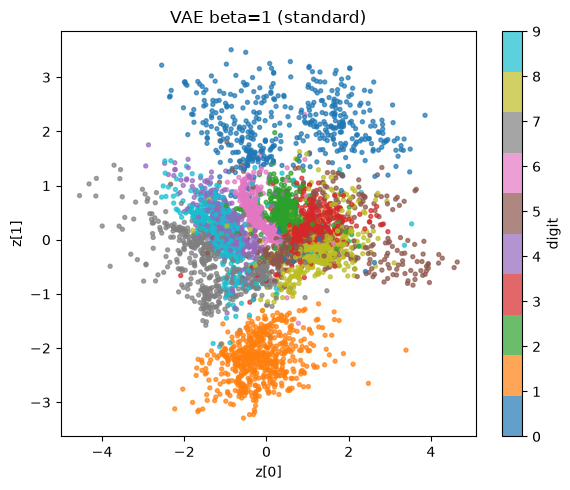

--- latent map: beta=4 ---


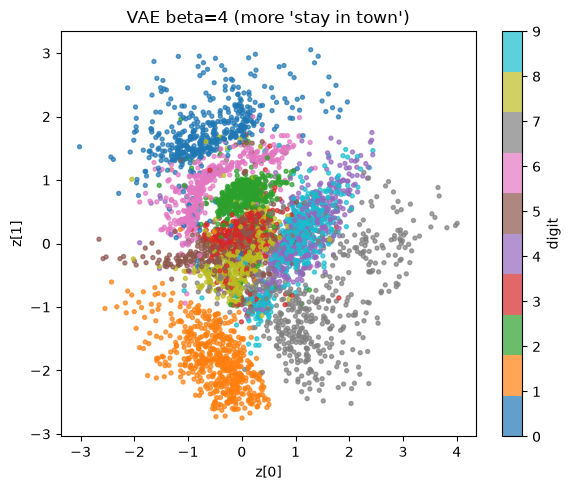

--- invented-digit grids ---


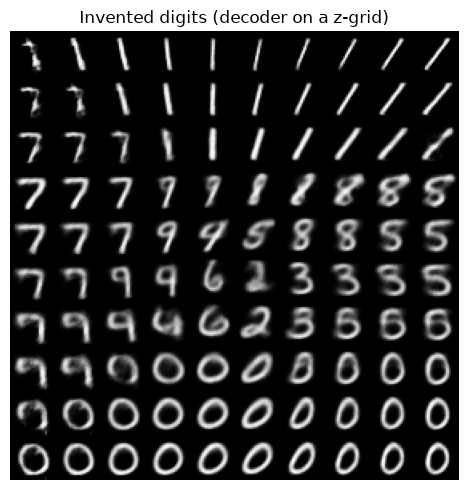

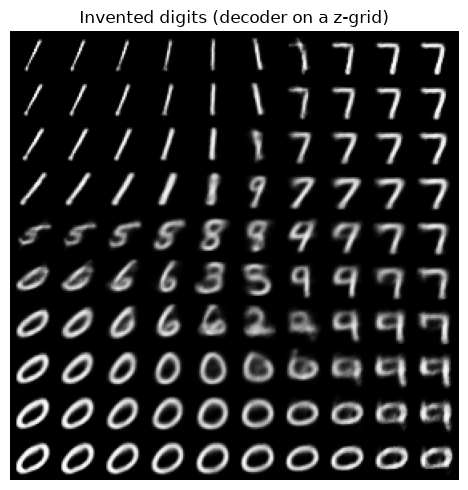


--- reconstructions (same test batch) ---


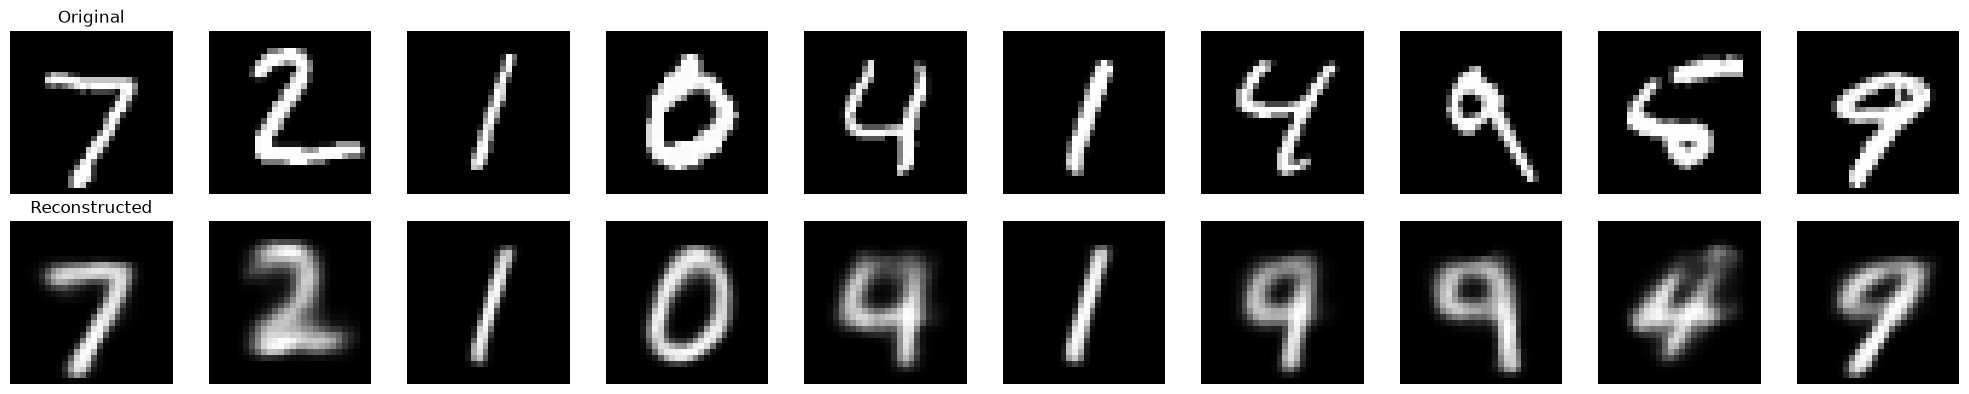

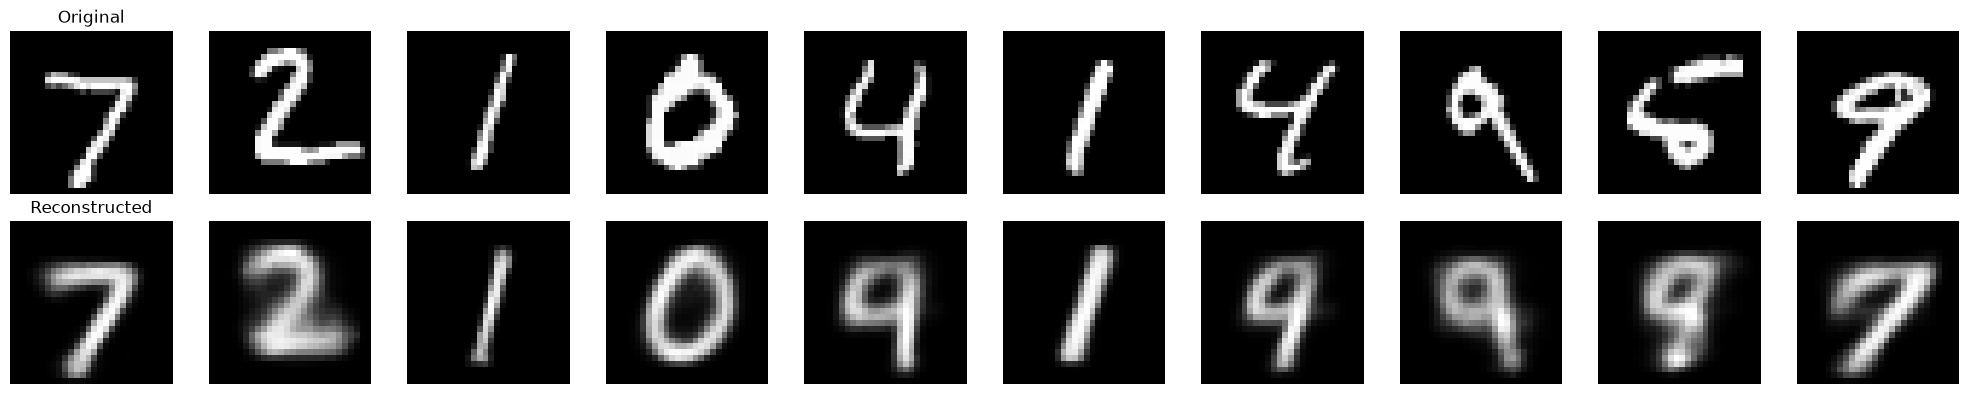

In [15]:
# =============================================================================
# MINI-PROJECT — denoise digits, then turn up the VAE "stay in town" knob
# =============================================================================
#
# Task 1  Denoising AE: hear a scratchy digit, redraw the clean one.
# Task 2  β-VAE: same VAE, but KL homework is 4× louder (beta=4).
# Task 3  save weights + recap  (next cell)
#

# ---------------------------------------------------------------------------
# TASK 1 — Denoising Autoencoder
# ---------------------------------------------------------------------------
# Plain AE: clean photo in → clean sketch out.
# DAE:      noisy photo in → still asked for the CLEAN sketch.
#
# Like teaching the earpiece to ignore static:
#   input  = clean digit + Gaussian snow (clamped back to 0..1)
#   target = the clean digit, not the snowy one
#
# noise_std=0.3 is a visible sprinkle, not total white-out.
#

def train_denoising_autoencoder(model, train_loader, epochs=10, lr=1e-3, noise_std=0.3):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    model.train()

    for epoch in range(epochs):
        total_loss = 0.0
        for x, _ in train_loader:
            x = x.to(device)
            x_flat = x.view(x.size(0), -1)

            noise = torch.randn_like(x) * noise_std
            x_noisy = torch.clamp(x + noise, 0, 1)

            x_recon = model(x_noisy)  # sees snow; must still draw clean
            loss = F.binary_cross_entropy(x_recon, x_flat, reduction="mean")

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * x.size(0)

        print(f"Epoch {epoch+1:2d} | DAE Loss: {total_loss/len(train_loader.dataset):.4f}")


dae = Autoencoder(latent_dim=32).to(device)
train_denoising_autoencoder(dae, train_loader, epochs=10)


def show_denoising(model, test_loader, noise_std=0.3, num_images=10):
    """Row 1 clean, row 2 snowy, row 3 DAE sketch from the snowy input."""
    model.eval()
    x, _ = next(iter(test_loader))
    x = x[:num_images].to(device)
    x_noisy = torch.clamp(x + torch.randn_like(x) * noise_std, 0, 1)

    with torch.no_grad():
        x_recon = model(x_noisy).view(num_images, 1, 28, 28).cpu()

    fig, axes = plt.subplots(3, num_images, figsize=(2 * num_images, 6))
    for i in range(num_images):
        axes[0, i].imshow(x[i].cpu().squeeze(), cmap="gray")
        axes[0, i].axis("off")
        axes[1, i].imshow(x_noisy[i].cpu().squeeze(), cmap="gray")
        axes[1, i].axis("off")
        axes[2, i].imshow(x_recon[i].squeeze(), cmap="gray")
        axes[2, i].axis("off")

    axes[0, 0].set_title("Original")
    axes[1, 0].set_title("Noisy")
    axes[2, 0].set_title("Denoised")
    plt.tight_layout()
    plt.show()


show_denoising(dae, test_loader)

# ---------------------------------------------------------------------------
# TASK 2 — helpers: 2-D map and a sheet of invented digits
# ---------------------------------------------------------------------------
# (These were called before they existed — that's the NameError.)
#

def plot_latent_space_2d(model, test_loader, device, n_max=5000, title="2-D latent map"):
    """Each test digit → mu (2 numbers) → one colored dot (color = 0..9)."""
    model.eval()
    zs, ys = [], []
    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device)
            mu, _ = model.encode(x)
            zs.append(mu.cpu())
            ys.append(y)
            if sum(len(t) for t in ys) >= n_max:
                break
    z = torch.cat(zs)[:n_max].numpy()
    y = torch.cat(ys)[:n_max].numpy()

    plt.figure(figsize=(6, 5))
    sc = plt.scatter(z[:, 0], z[:, 1], c=y, cmap="tab10", s=8, alpha=0.7)
    plt.colorbar(sc, ticks=range(10), label="digit")
    plt.xlabel("z[0]")
    plt.ylabel("z[1]")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_generated_grid(model, latent_dim=2, n=10, span=3.0):
    """Walk a grid in z-space (no real photos) and let the decoder invent digits."""
    model.eval()
    grid_x = torch.linspace(-span, span, n)
    grid_y = torch.linspace(-span, span, n)
    canvas = np.zeros((n * 28, n * 28))
    with torch.no_grad():
        for i, yi in enumerate(grid_y):
            for j, xi in enumerate(grid_x):
                z = torch.zeros(1, latent_dim, device=device)
                z[0, 0], z[0, 1] = xi, yi
                digit = model.decode(z).view(28, 28).cpu().numpy()
                canvas[i * 28 : (i + 1) * 28, j * 28 : (j + 1) * 28] = digit
    plt.figure(figsize=(5, 5))
    plt.imshow(canvas, cmap="gray")
    plt.axis("off")
    plt.title("Invented digits (decoder on a z-grid)")
    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------------------------
# TASK 2 — β-VAE (beta=4) vs the beta=1 map from the previous cell (vae_2d)
# ---------------------------------------------------------------------------
# beta=1  → recon and "stay in town" are equal volume
# beta=4  → "stay in town" is shouted 4× louder
# Effect you usually see:
#   + dimensions specialize more (one axis ~ thickness, one ~ slant, …)
#   − sketches get blurrier / less detailed  (recon loss stays higher)
#

vae_beta4 = VAE(latent_dim=2).to(device)
train_vae(vae_beta4, train_loader, epochs=10, beta=4.0)

print("\n--- latent map: beta=1 (vae_2d from earlier cell) ---")
plot_latent_space_2d(vae_2d, test_loader, device, title="VAE beta=1 (standard)")

print("--- latent map: beta=4 ---")
plot_latent_space_2d(vae_beta4, test_loader, device, title="VAE beta=4 (more 'stay in town')")

print("--- invented-digit grids ---")
plot_generated_grid(vae_2d, latent_dim=2)
plot_generated_grid(vae_beta4, latent_dim=2)

print("\n--- reconstructions (same test batch) ---")
show_reconstructions(vae_2d, test_loader, is_vae=True)
show_reconstructions(vae_beta4, test_loader, is_vae=True)

# ---------------------------------------------------------------------------
# HOW TO READ THE OUTPUT
# ---------------------------------------------------------------------------
# Task 1 DAE Loss: 0.23 → 0.11  (your run)
#   Same yardstick as the plain AE (mean BCE). Starts a bit worse than AE's
#   0.21 because the INPUT is noisier. Ends ~0.11 vs AE ~0.096 — close.
#   Plot: middle row snowy, bottom row should look more like the top than
#   like the snow. If bottom is still speckled, noise_std is too high or
#   train longer.
#
# Task 2 beta=4: Loss 194 → 161 | Recon 186 → 142 | KL 2.0 → 4.5
#   Compare to vae_2d (beta=1) epoch 10: Loss 144 | Recon 138 | KL 6.3
#   Wait — KL is SMALLER here (4.5 vs 6.3) even with bigger beta?
#   beta multiplies KL in the LOSS, so the trainer fights harder to keep
#   KL down. Recon stays a bit worse (142 vs 138) — blurrier sketches.
#   (Runs vary; look for the PATTERN: higher beta → recon harder, map
#    more regular / more overlapping blobs.)
#
# Scatter plot:
#   Each color = a digit. Nice VAE: same colors clump. beta=4 often makes
#   a tighter blob around 0 (the "town").
#
# Generated grid:
#   Smooth morphing 3→8→… is the dream. Holes or junk at the edges =
#   empty lockers. beta=4 grids are often smoother but foggier.


In [16]:
# =============================================================================
# TASK 3 — save artifacts + one-page recap (ELBO in plain English)
# =============================================================================
#
# Portfolio checklist for this notebook:
#   [x] AE trained on MNIST
#   [x] VAE (20-D and 2-D) with ELBO = recon + KL
#   [x] Denoising AE
#   [x] β-VAE (beta=4) vs beta=1 maps
#   [x] 2-D scatter + generated grid
#

from pathlib import Path

_out = Path("week3") if Path("week3").is_dir() else Path(".")
for name, obj in [
    ("ae_mnist.pt", ae),
    ("vae_mnist_20.pt", vae_20),
    ("vae_mnist_2d.pt", vae_2d),
    ("dae_mnist.pt", dae),
    ("vae_mnist_beta4.pt", vae_beta4),
]:
    path_pt = _out / name
    torch.save(obj.state_dict(), path_pt)
    print("saved", path_pt)

# ---------------------------------------------------------------------------
# ELBO (what the VAE is actually maximizing), without the textbook fog
# ---------------------------------------------------------------------------
# We cannot easily maximize "probability of this photo under the model".
# We maximize a LOWER BOUND of that — the ELBO — which splits into:
#
#   ELBO ≈  -recon_loss  -  KL
#   so minimizing  (recon + beta*KL)  is the same homework with a minus sign.
#
# Recon  = "decoder, redraw the photo from z"
# KL     = "encoder, keep neighborhoods near the standard blob at 0"
# Reparameterize = pick z = mu + sigma*noise so gradients still reach mu/sigma
#                  (you cannot backprop through a raw random.sample)
#
# Limitations you already saw:
#   Tiny z (2-D) → blurry digits, but you can plot the map.
#   Bigger z (20-D) → better sketches, map lives in 20-D (no poster).
#   Denoising works, not magic — heavy snow still wins.
#   beta too high → pretty map, mushy reconstructions.
#   This is NOT your live Correction-GPT. It's the compress/generate cousin.
#
# ---------------------------------------------------------------------------
# HOW TO READ THIS CELL
# ---------------------------------------------------------------------------
# saved week3/ae_mnist.pt ...
#   Reload later with the matching class, e.g.:
#     ae = Autoencoder(latent_dim=32)
#     ae.load_state_dict(torch.load("week3/ae_mnist.pt", map_location="cpu"))


saved ae_mnist.pt
saved vae_mnist_20.pt
saved vae_mnist_2d.pt
saved dae_mnist.pt
saved vae_mnist_beta4.pt


# ELBO in one breath

The VAE does **not** directly maximize \(p(x)\). It maximizes a **lower bound** (ELBO):

\[
\log p(x) \ge \underbrace{\mathbb{E}_{q(z|x)}[\log p(x|z)]}_{\text{rebuild the photo}} - \underbrace{D_{KL}(q(z|x)\,\|\,p(z))}_{\text{keep z-neighborhoods in town}}
\]

In this notebook that is exactly `vae_loss`: **BCE reconstruction + β × KL**.

**Reparameterization:** \(z = \mu + \sigma \odot \varepsilon,\ \varepsilon \sim \mathcal{N}(0,1)\) so training can still twist \(\mu\) and \(\sigma\).
